In [71]:
#importing the required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
#Ignore harmless warnings
import warnings
warnings.filterwarnings('ignore')

In [73]:
#chek all the data set available in seaborn
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [74]:
#import penguins dataset
df = sns.load_dataset('penguins')

In [75]:
df.info() #Information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [76]:
print(f'The penguins data has {df.shape[0]} rows and {df.shape[1]} columns.')

The penguins data has 344 rows and 7 columns.


In [77]:
#Sample of Penguine data set
df .head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [78]:
#check if there any missing value
count = df.isnull().sum()
percentage = df.isnull().mean() * 100

missingvalue = pd.concat([count, percentage], axis=1)
missingvalue.columns = ['Missing Count', 'Missing Percentage']

# Sort for readability
missingvalue = missingvalue.sort_values(by='Missing Percentage', ascending=False)

# Apply styling: red for high %, yellow for moderate, green for low
styled_missing = (
    missingvalue.style
    .background_gradient(subset=['Missing Percentage'], cmap='RdYlGn_r')
    .format({'Missing Percentage': '{:.2f}%'})
)

styled_missing


,Missing Count,Missing Percentage
sex,11,3.20%
bill_length_mm,2,0.58%
bill_depth_mm,2,0.58%
flipper_length_mm,2,0.58%
body_mass_g,2,0.58%
species,0,0.00%
island,0,0.00%


In [79]:
print(f"{'Variable':<20}{'Missing %':<20}{'Treatment':<30}")
print("-"*70)

for col in missingvalue[missingvalue["Missing Count"] > 0].index:
    if df[col].dtype == 'object':
        treatment = "MODE OR MEDIAN"
    else:
        treatment = "MEAN"
    
    print(f"{col:<20}{missingvalue.loc[col, 'Missing Percentage']:.2f}%{'':<10}{treatment:<30}")


Variable            Missing %           Treatment                     
----------------------------------------------------------------------
sex                 3.20%          MODE OR MEDIAN                
bill_length_mm      0.58%          MEAN                          
bill_depth_mm       0.58%          MEAN                          
flipper_length_mm   0.58%          MEAN                          
body_mass_g         0.58%          MEAN                          


In [80]:
#Performing missing value treatment
for col in missingvalue[missingvalue["Missing Count"] > 0].index:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0],inplace=True)
    else:
        df[col].fillna(df[col].median(),inplace=True)

In [81]:
#check if there any missing value after missing value treatment
count = df.isnull().sum()
percentage = df.isnull().mean() * 100

missingvalue = pd.concat([count, percentage], axis=1)
missingvalue.columns = ['Missing Count', 'Missing Percentage']

# Sort for readability
missingvalue = missingvalue.sort_values(by='Missing Percentage', ascending=False)

# Apply styling: red for high %, yellow for moderate, green for low
styled_missing = (
    missingvalue.style
    .background_gradient(subset=['Missing Percentage'], cmap='RdYlGn_r')
    .format({'Missing Percentage': '{:.2f}%'})
)

styled_missing

,Missing Count,Missing Percentage
species,0,0.00%
island,0,0.00%
bill_length_mm,0,0.00%
bill_depth_mm,0,0.00%
flipper_length_mm,0,0.00%
body_mass_g,0,0.00%
sex,0,0.00%


In [82]:
# what happens to body mass when flipper length increases

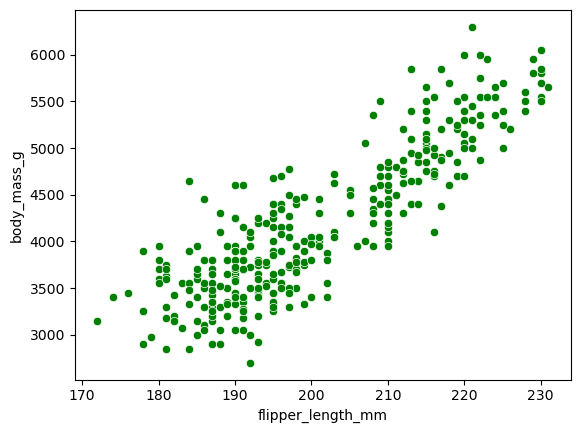

In [85]:
sns.scatterplot(data =df,x='flipper_length_mm',y='body_mass_g',color='g')
plt.show()

In [100]:
def correlation_value(data, y, x=[]):
    
    # If y is a single column name
    if isinstance(y, str):
        s_corr = data[x].corrwith(data[y])
    else:
        s_corr = data[x].corr(data[y])
    
    # Iterate through correlations if multiple
    if isinstance(s_corr, pd.Series):
        for col, val in s_corr.items():
            if val > 0:
                r = "Positively Correlated"
            elif val < 0:
                r = "Negatively Correlated"
            else:
                r = "No Correlation"
            print(f"The correlation between {col} and {y} is {r} with the value of {val:.4f}")
    else:
        # Single correlation value
        if s_corr > 0:
            r = "Positively Correlated"
        elif s_corr < 0:
            r = "Negatively Correlated"
        else:
            r = "No Correlation"
        print(f"The correlation between {x} and {y} is {r} with the value of {s_corr:.4f}")



In [101]:
correlation_value(df,'body_mass_g',['flipper_length_mm'])

The correlation between flipper_length_mm and body_mass_g is Positively Correlated with the value of 0.8712


In [87]:
# check the correlation between body_mass_g and flipper_length_mm
s_corr = df['flipper_length_mm'].corr(df['body_mass_g'])
s_corr

0.8712211273375564

In [122]:
from matplotlib import colormaps
list(colormaps)  # shows all available colormaps

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',
 'inferno_r',
 'plasma_r',
 'viri

<Axes: >

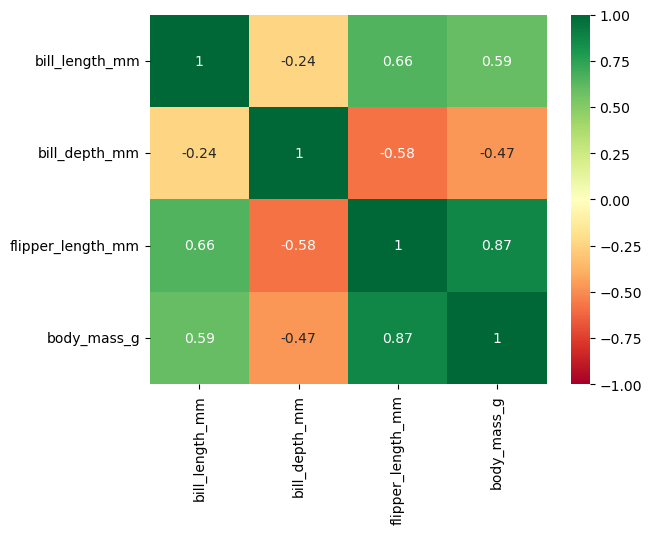

In [123]:
#Heat  map for easy understanding
sns.heatmap(df.corr(numeric_only=True),annot = True,vmin=-1,vmax=1,cmap='RdYlGn')

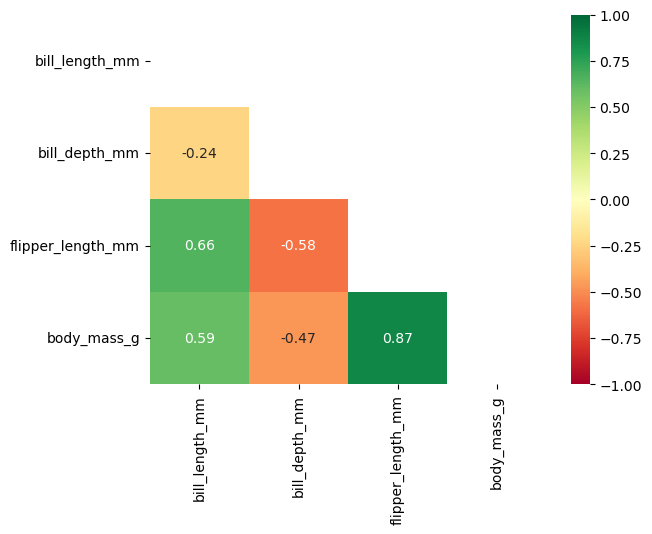

In [126]:
cor =df.corr(numeric_only=True)
upper = np.triu(cor)
lower =np.tril(cor)
sns.heatmap(df.corr(numeric_only=True),annot = True,vmin=-1,vmax=1,cmap='RdYlGn',mask=upper)
plt.show()

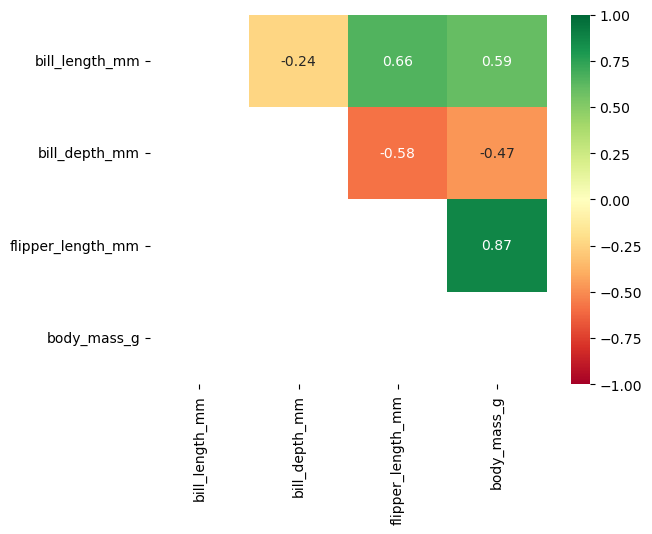

In [127]:
sns.heatmap(df.corr(numeric_only=True),annot = True,vmin=-1,vmax=1,cmap='RdYlGn',mask=lower)
plt.show()